In [44]:
# 1. IMPORT LIBRARIES

In [45]:
%pip install numpy pandas matplotlib seaborn scikit-learn
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 2. Data Loading

The provided data should be stored in a CSV file named `car_data.csv`.


In [46]:
df = pd.read_csv("car_data.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1000, 5)


,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


In [47]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [48]:
display(df.describe(include="all"))


,User ID,Gender,Age,AnnualSalary,Purchased
count,1000.000000,1000,1000.000000,1000.000000,1000.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,516,NaN,NaN,NaN
mean,500.500000,NaN,40.106000,72689.000000,0.402000
std,288.819436,NaN,10.707073,34488.341867,0.490547
min,1.000000,NaN,18.000000,15000.000000,0.000000
25%,250.750000,NaN,32.000000,46375.000000,0.000000
50%,500.500000,NaN,40.000000,72000.000000,0.000000
75%,750.250000,NaN,48.000000,90000.000000,1.000000


In [49]:
df.isnull().sum()


User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

In [50]:
df.duplicated().sum()


np.int64(0)

In [51]:
df.drop(['User ID'],axis=1,inplace=True)


Text(0.5, 0.98, 'Visualizing Continuous Columns')

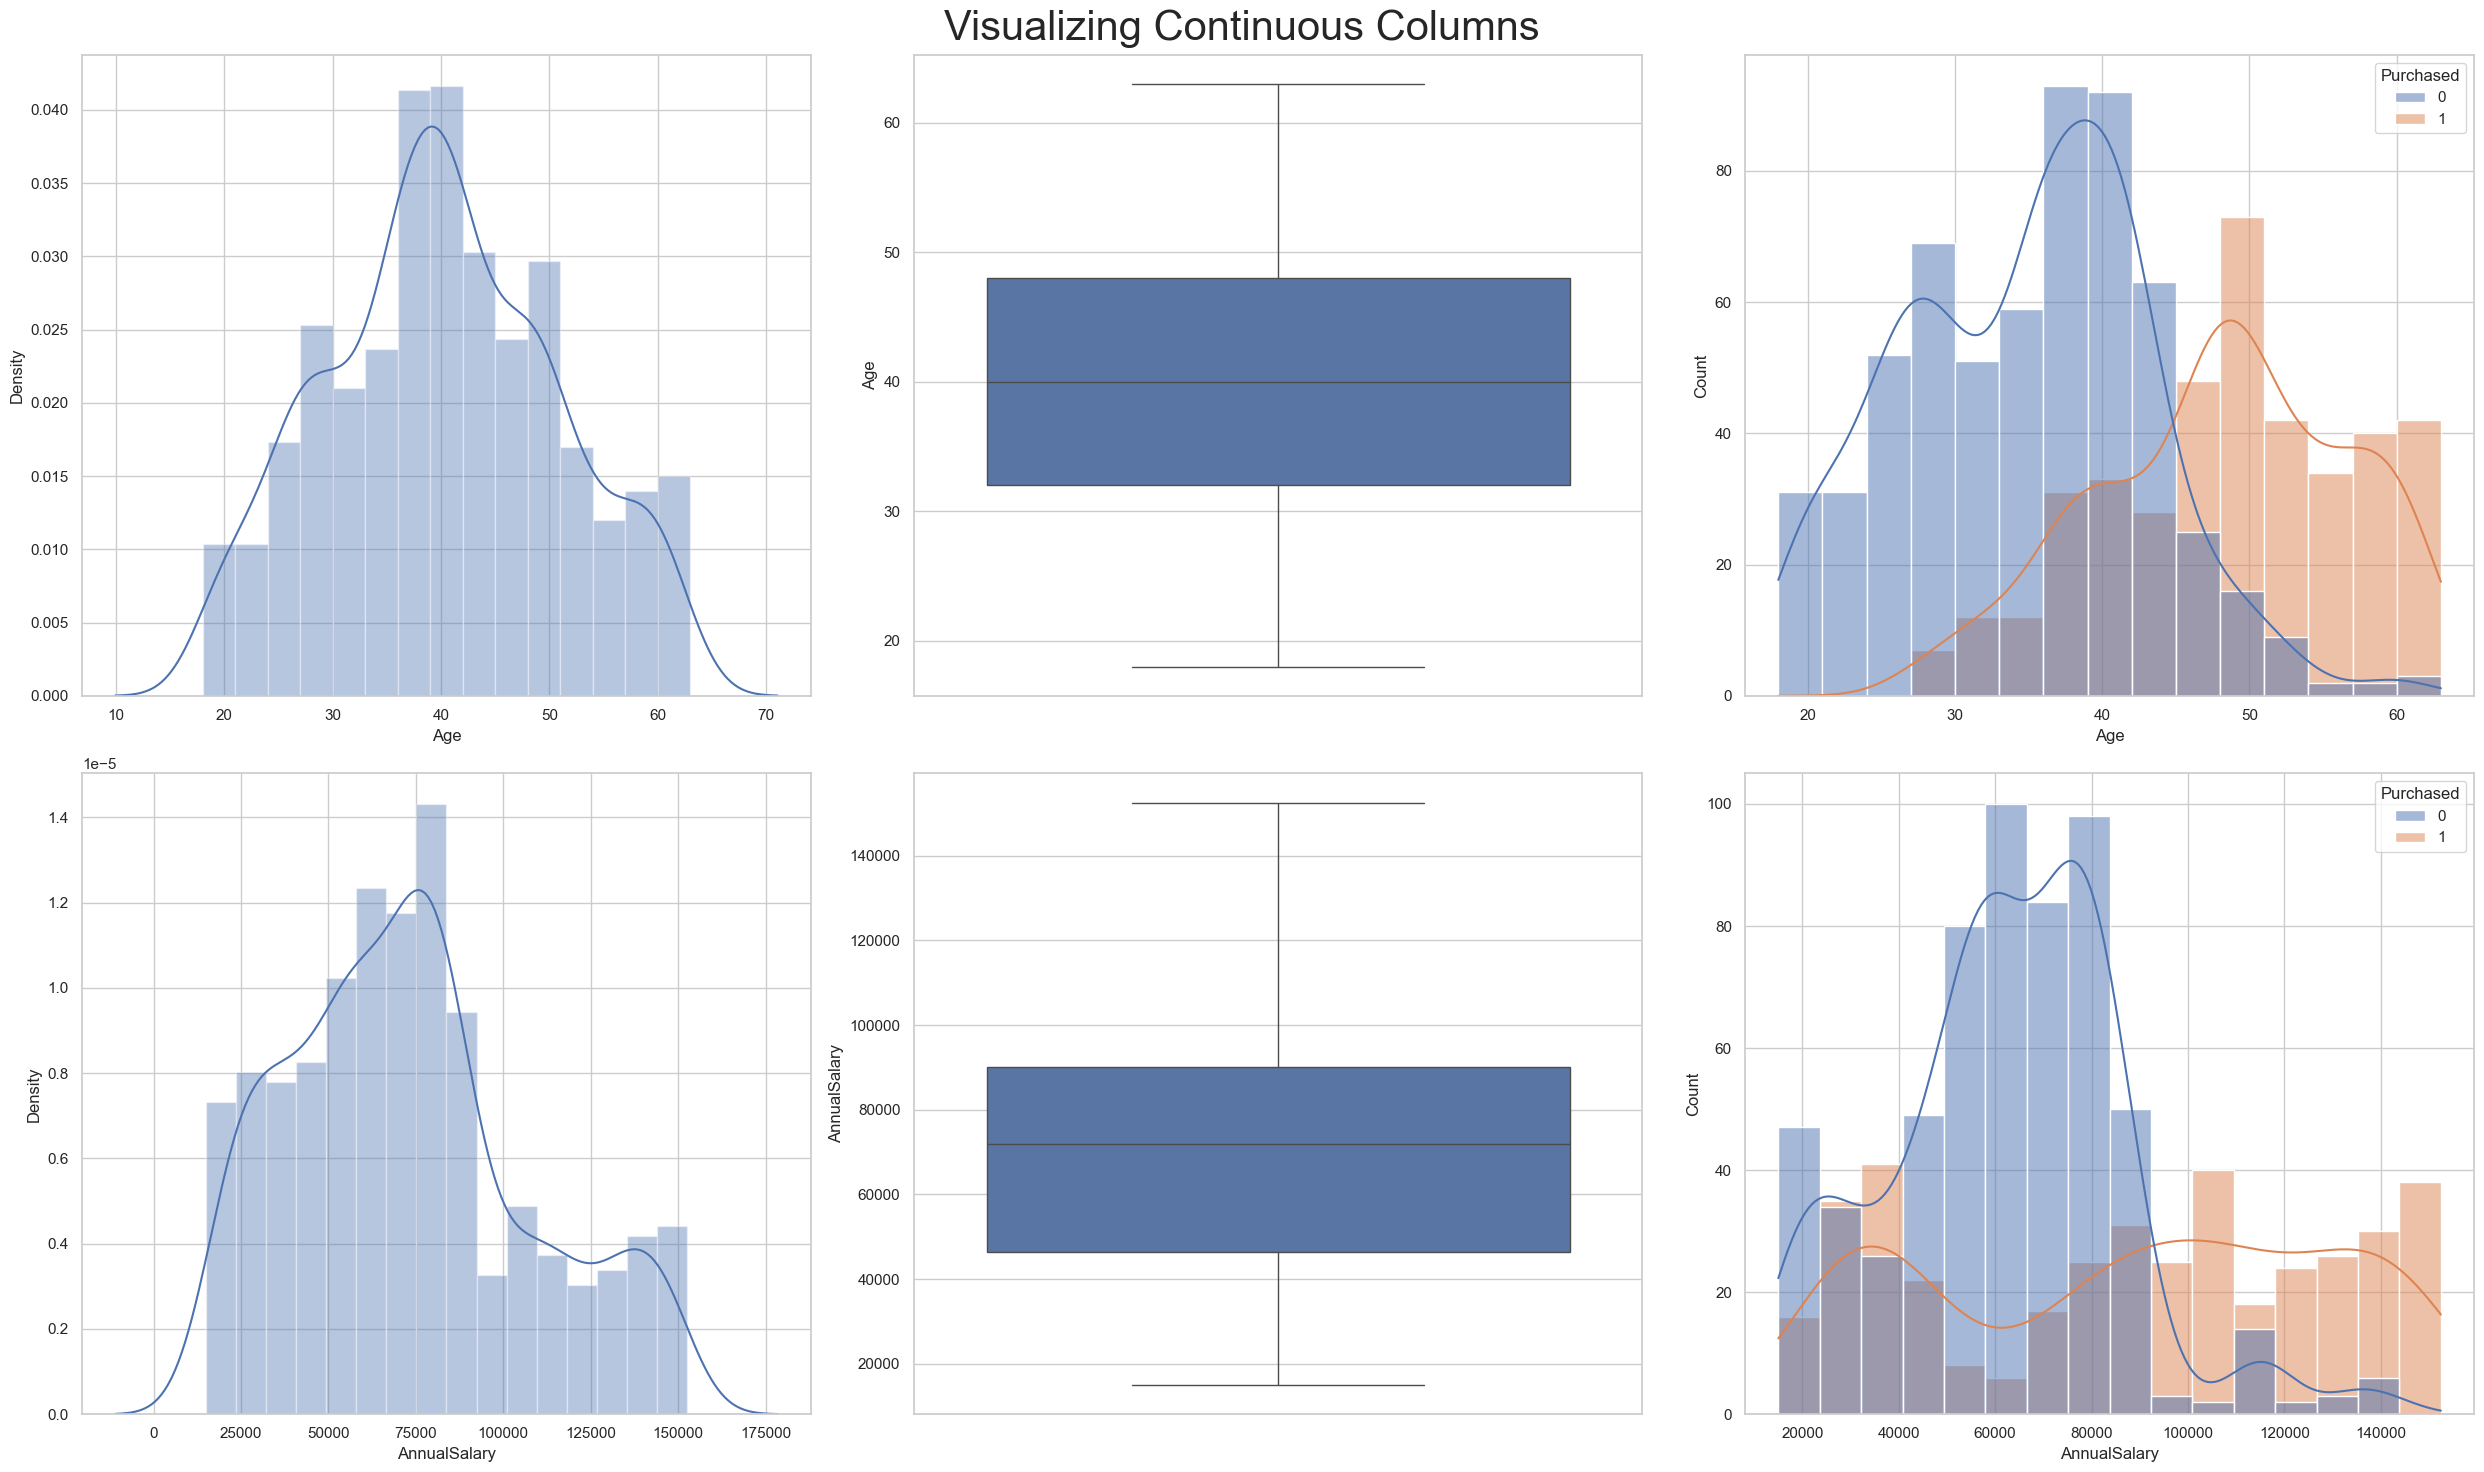

In [52]:
import warnings
warnings.filterwarnings('ignore')

fig,ax=plt.subplots(2,3,figsize=(25,15))
sns.distplot(df['Age'],ax=ax[0,0])
sns.boxplot(y=df['Age'],ax=ax[0,1])
sns.histplot(data=df,x='Age',ax=ax[0,2],hue='Purchased',kde=True)

sns.distplot(df['AnnualSalary'],ax=ax[1,0])
sns.boxplot(y=df['AnnualSalary'],ax=ax[1,1])
sns.histplot(data=df,x='AnnualSalary',ax=ax[1,2],hue='Purchased',kde=True)
    
fig.tight_layout()
fig.subplots_adjust(top=0.95)
plt.suptitle("Visualizing Continuous Columns",fontsize=30)

<Axes: xlabel='Gender', ylabel='count'>

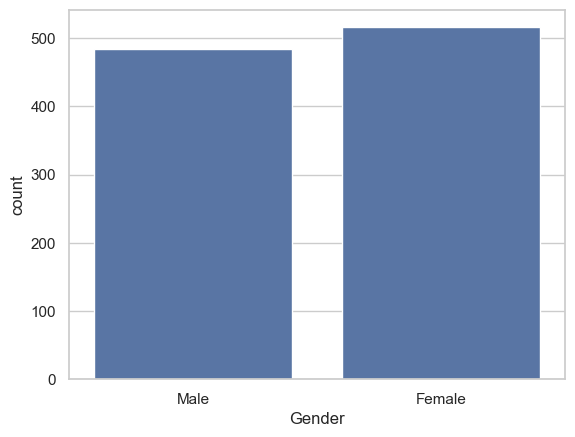

In [53]:
sns.countplot(data=df,x='Gender')


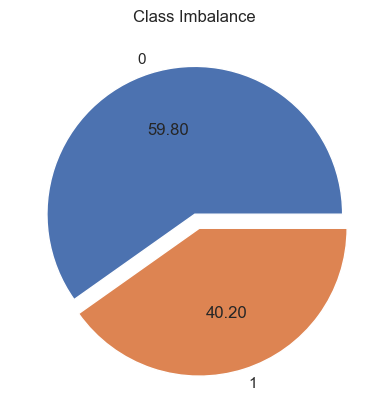

In [54]:
plt.pie(df['Purchased'].value_counts(),labels=df['Purchased'].value_counts().index,autopct='%.2f',explode=[0,0.1])
plt.title("Class Imbalance")
plt.show()

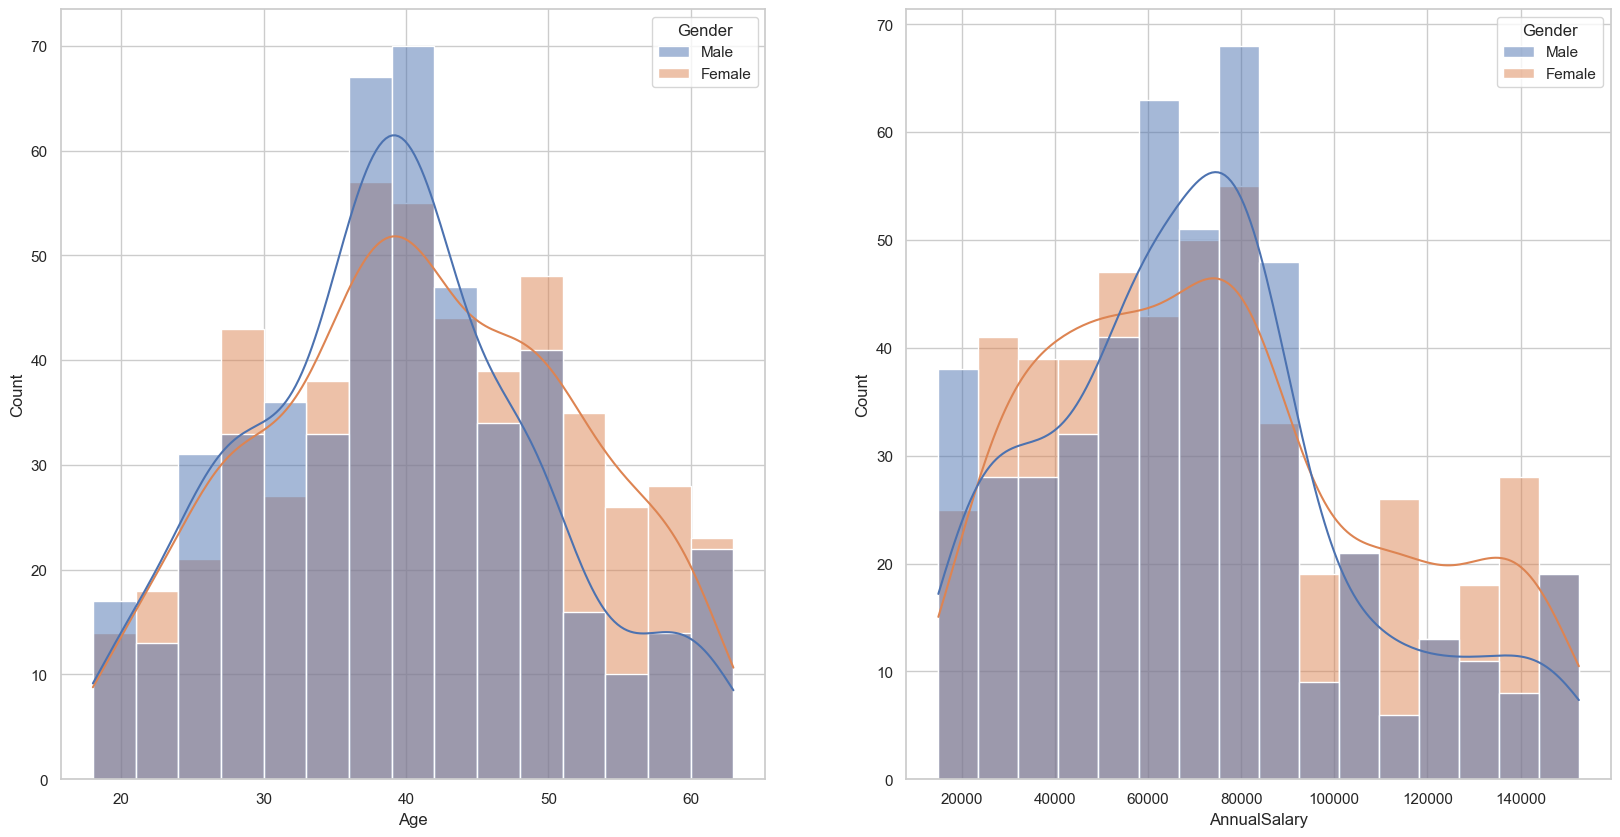

In [55]:
fig,ax=plt.subplots(1,2,figsize=(20,10))
sns.histplot(data=df,x='Age',ax=ax[0],hue='Gender',kde=True)
sns.histplot(data=df,x='AnnualSalary',ax=ax[1],hue='Gender',kde=True)

plt.show()

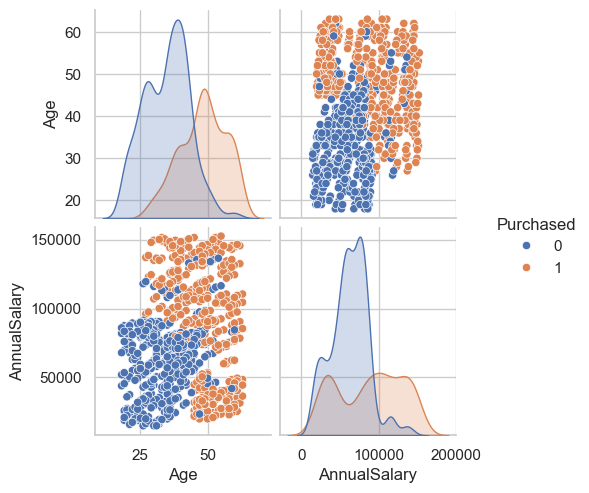

In [56]:
sns.pairplot(df,hue='Purchased')
plt.show()

<Axes: >

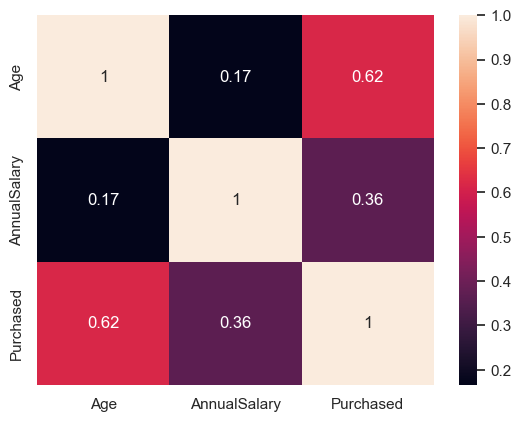

In [59]:
sns.heatmap(df.corr(numeric_only=True),annot=True)


In [75]:
%pip install ipywidgets
%pip install --upgrade nbformat ipython ipywidgets

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [76]:
%pip install plotly
%pip install nbformat

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [93]:
%pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 258 kB 1.2 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [94]:
import plotly.express as px

fig = px.scatter(
    df, 
    x='Age', 
    y='AnnualSalary',
    color='Purchased',
    symbol='Gender'
    )
fig.show(renderer="browser")

In [95]:
fig = px.density_contour(df, x='Age', y='AnnualSalary')
fig.show("browser")

# Data Preprocessing¶


In [96]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn import set_config
set_config(display='diagram')
transformer = ColumnTransformer(
    transformers=[
        ('Encoder',OneHotEncoder(drop='first',sparse_output=False),['Gender']),
        ('Yeo-Johnson',PowerTransformer(),['Age','AnnualSalary'])
        ]
)

In [97]:
transformer

ColumnTransformer(transformers=[('Encoder',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['Gender']),
                                ('Yeo-Johnson', PowerTransformer(),
                                 ['Age', 'AnnualSalary'])])

In [98]:
from sklearn.model_selection import train_test_split

x = df.drop(['Purchased'],axis=1)
y = df['Purchased']

X_train,X_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [99]:
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

In [101]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(
    X_train_transformed,
    y_train
)

# MODEL

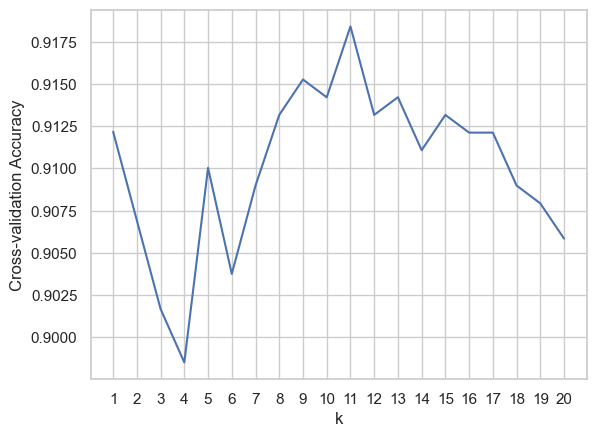

In [104]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

knn_scores=[]
k_range = range(1, 21)

for k in k_range:
    knn=KNeighborsClassifier(n_neighbors=k)
    scores=cross_val_score(knn,X_train_resampled,y_train_resampled,cv=5)
    knn_scores.append(scores.mean())


plt.plot(list(k_range),knn_scores)
plt.xticks(ticks=list(k_range))
plt.xlabel("k")
plt.ylabel("Cross-validation Accuracy")
plt.grid(True)
plt.show()

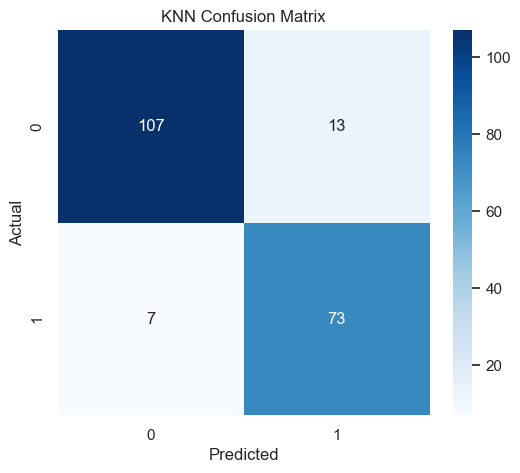

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.89      0.91       120
           1       0.85      0.91      0.88        80

    accuracy                           0.90       200
   macro avg       0.89      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1. Instantiate and fit KNN using resampled training data
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X_train_resampled, y_train_resampled)

# 2. Predict on transformed test set
y_pred = knn.predict(X_test_transformed)

# 3. Plot Confusion Matrix
confusion_knn = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_knn, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

# 4. Print Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

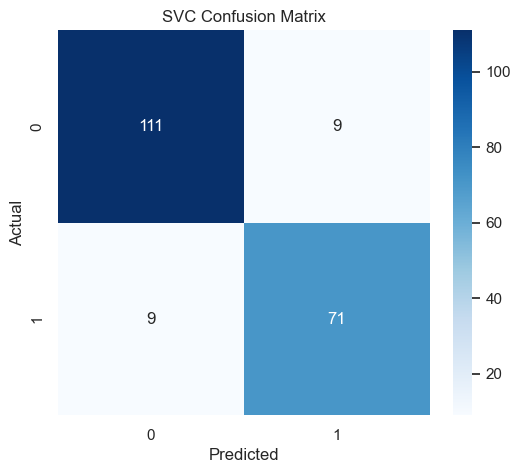

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       120
           1       0.89      0.89      0.89        80

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200


Best Parameters of SVC model is : {'kernel': 'rbf', 'gamma': 10, 'C': 1}



In [106]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# 1. Define hyperparameter distribution
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly']
}

# 2. Run RandomizedSearchCV on resampled training set
rcv = RandomizedSearchCV(SVC(), param_grid, cv=5, random_state=42)
rcv.fit(X_train_resampled, y_train_resampled)

# 3. Predict on untouched transformed test set
y_pred_svc = rcv.predict(X_test_transformed)

# 4. Confusion Matrix Visual
confusion_svc = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_svc, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVC Confusion Matrix")
plt.show()

# 5. Output Metrics and Best Hyperparameters
print("Classification Report:\n")
print(classification_report(y_test, y_pred_svc))
print(f"\nBest Parameters of SVC model is : {rcv.best_params_}\n")

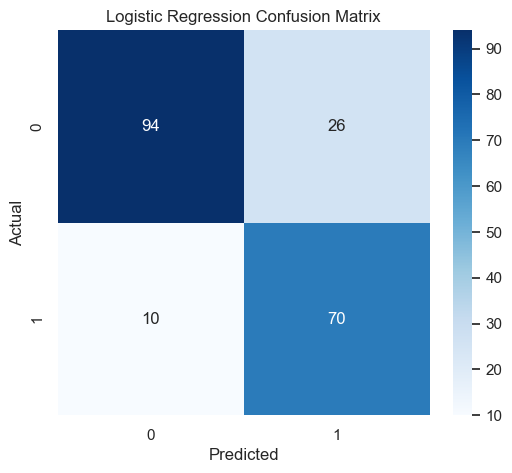

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.78      0.84       120
           1       0.73      0.88      0.80        80

    accuracy                           0.82       200
   macro avg       0.82      0.83      0.82       200
weighted avg       0.83      0.82      0.82       200


Best Parameters of Logistic Regression model: {'max_iter': 300, 'C': 0.01}



In [107]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# 1. Define hyperparameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'max_iter': [50, 75, 100, 200, 300, 400, 500, 700]
}

# 2. Run RandomizedSearchCV on resampled training set
log = RandomizedSearchCV(
    LogisticRegression(solver='lbfgs'), 
    param_grid, 
    cv=5, 
    random_state=42
)
log.fit(X_train_resampled, y_train_resampled)

# 3. Predict on untouched transformed test set
y_pred_log = log.predict(X_test_transformed)

# 4. Confusion Matrix Visual
confusion_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_log, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# 5. Output Metrics and Best Hyperparameters
print("Classification Report:\n")
print(classification_report(y_test, y_pred_log))
print(f"\nBest Parameters of Logistic Regression model: {log.best_params_}\n")

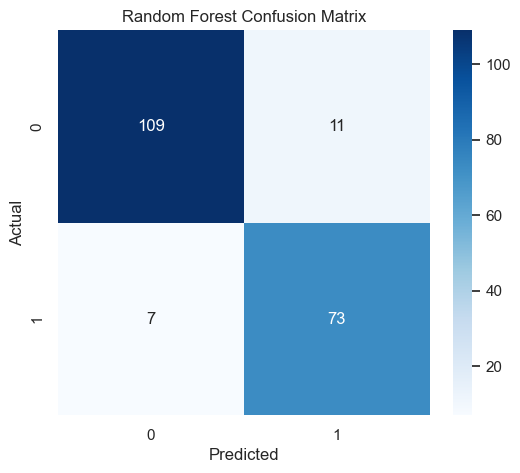

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.91      0.92       120
           1       0.87      0.91      0.89        80

    accuracy                           0.91       200
   macro avg       0.90      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200


Best Parameter: {'n_estimators': 100, 'max_features': 'log2', 'max_depth': 8, 'criterion': 'gini'}



In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# 1. Define hyperparameter grid (removed deprecated 'auto' from max_features)
param_grid = {
    'n_estimators': [50, 75, 100, 150, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [4, 5, 6, 7, 8, 16],
    'criterion': ['gini', 'entropy']
}

# 2. Run RandomizedSearchCV on SMOTE-resampled training data
rcv = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid, 
    cv=5, 
    random_state=42
)
rcv.fit(X_train_resampled, y_train_resampled)

# 3. Predict on untouched transformed test set
y_pred_rcv = rcv.predict(X_test_transformed)

# 4. Confusion Matrix Visual
confusion_rcv = confusion_matrix(y_test, y_pred_rcv)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_rcv, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

# 5. Output Metrics and Best Hyperparameters
print("Classification Report:\n")
print(classification_report(y_test, y_pred_rcv))
print(f"\nBest Parameter: {rcv.best_params_}\n")

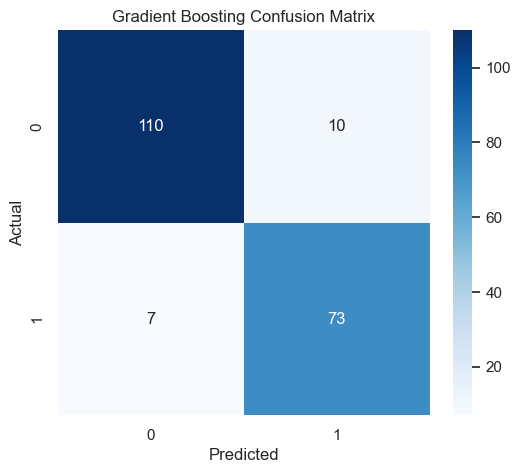

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       120
           1       0.88      0.91      0.90        80

    accuracy                           0.92       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.92      0.92      0.92       200


Best Parameter: {'n_estimators': 75, 'learning_rate': 0.1}



In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# 1. Define hyperparameter grid
param_grid = {
    'learning_rate': [0.05, 0.075, 0.1, 0.25, 0.5, 0.75, 1],
    'n_estimators': [50, 75, 100, 150, 200, 300]
}

# 2. Run RandomizedSearchCV on SMOTE-resampled training data
gbc = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42), 
    param_grid, 
    cv=5, 
    random_state=42
)
gbc.fit(X_train_resampled, y_train_resampled)

# 3. Predict on untouched transformed test set
y_pred_gbc = gbc.predict(X_test_transformed)

# 4. Confusion Matrix Visual
confusion_gbc = confusion_matrix(y_test, y_pred_gbc)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_gbc, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

# 5. Output Metrics and Best Hyperparameters
print("Classification Report:\n")
print(classification_report(y_test, y_pred_gbc))
print(f"\nBest Parameter: {gbc.best_params_}\n")

In [117]:
%pip install lightgbm
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.9 MB 1.4 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


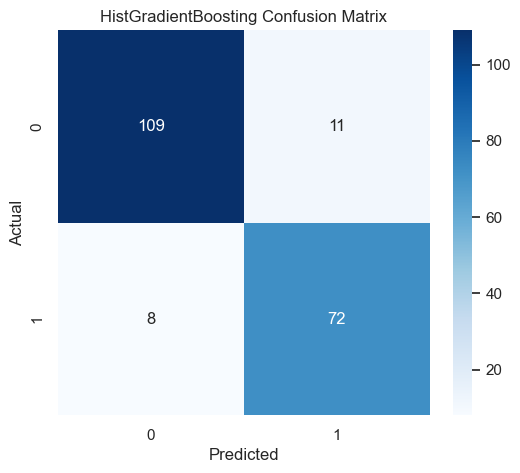

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       120
           1       0.87      0.90      0.88        80

    accuracy                           0.91       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.91      0.91      0.91       200



In [121]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1. Instantiate model
model = HistGradientBoostingClassifier(random_state=42)

# 2. Fit using SMOTE-resampled training data
model.fit(X_train_resampled, y_train_resampled)

# 3. Predict on untouched transformed test set
y_pred_hgb = model.predict(X_test_transformed)

# 4. Plot Confusion Matrix
confusion_hgb = confusion_matrix(y_test, y_pred_hgb)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_hgb, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("HistGradientBoosting Confusion Matrix")
plt.show()

# 5. Output Metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred_hgb))

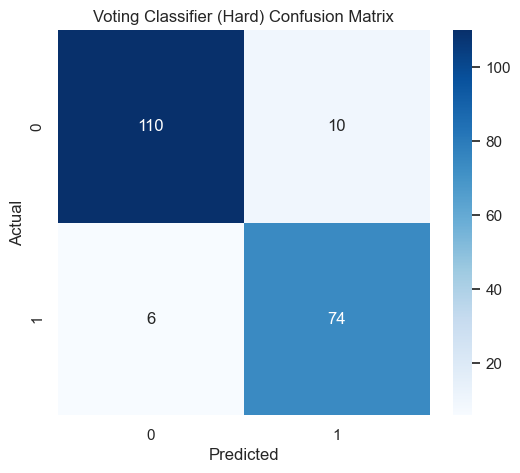

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.92      0.93       120
           1       0.88      0.93      0.90        80

    accuracy                           0.92       200
   macro avg       0.91      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



In [122]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

# 1. Build list of estimators using tuned hyperparameters
estimators = [
    ('RFC', RandomForestClassifier(n_estimators=300, max_features='log2', max_depth=8, random_state=42)),
    ('SVC', SVC(kernel='rbf', gamma=1, C=100, probability=True, random_state=42)),
    ('GBC', GradientBoostingClassifier(n_estimators=50, learning_rate=0.05, random_state=42))
]

# 2. Instantiate Voting Classifier (using 'hard' voting)
vot_hard = VotingClassifier(estimators=estimators, voting='hard')

# 3. Fit on SMOTE-balanced training set
vot_hard.fit(X_train_resampled, y_train_resampled)

# 4. Predict on untouched transformed test set
y_pred_vot = vot_hard.predict(X_test_transformed)

# 5. Plot Confusion Matrix
confusion_vot = confusion_matrix(y_test, y_pred_vot)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_vot, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Voting Classifier (Hard) Confusion Matrix")
plt.show()

# 6. Output Metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred_vot))